# Customer Churn Analysis in Telecom: Identifying Key Drivers and Revenue Impact

## Problem Statement

In the telecom industry, keeping customers is very important for steady revenue and business growth. The company is losing customers, and this may be reducing its overall income. The goal of this analysis is to understand why customers are leaving, which customers are at risk, and how this is affecting revenue. By studying the data, we want to find clear reasons for churn and suggest ways to improve customer retention.

## Objective

The main objective of this project is to analyze customer churn and understand what factors are causing customers to leave. We want to compare churned, stayed, and newly joined customers to see how they are different. We also aim to measure how churn is affecting revenue and identify practical steps the company can take to reduce customer loss.

## Research Questions

1) How many customers joined and how many customers churned during the last quarter?

2) Are churned customers different from stayed customers in terms of tenure, monthly charges, and revenue?

3) Which factors (such as contract type, tenure, service type, or customer support) are most strongly related to churn?

4) Is the company losing high-value customers, and how much revenue is being lost due to churn?

5) What actions can the company take to reduce churn and improve customer retention?

## Dataset Description

This dataset contains information about 7,043 telecom customers. Each row represents one customer and includes details about their personal profile, services used, contract type, billing information, and churn status.
The dataset helps us understand customer behavior by showing how long customers stayed with the company, how much they paid, what services they used, and whether they stayed, joined, or churned during the last quarter.

It also includes information about why customers left the company, which helps us identify the main reasons for churn and find possible solutions. 

## Important Columns for Analysis

Not all columns are equally important for answering our business questions. We will focus on the following key columns:

- Customer Status – Shows whether the customer Stayed, Churned, or Joined. This is our main target variable.

- Tenure in Months – Indicates how long the customer has been with the company. This helps us understand lifecycle risk.

- Monthly Charge – Shows how much the customer pays every month. This may influence churn.

- Total Revenue – Represents the total amount earned from the customer. This helps identify high-value customers.

- Contract – Shows whether the customer has a Month-to-Month, One-Year, or Two-Year contract. Contract type may strongly impact churn.

- Internet Type / Services Used – Helps us see whether certain service types are linked to higher churn.

- Churn Category – Provides broad reasons for churn (e.g., competitor, service issue).

- Churn Reason – Gives specific reasons why the customer left. This is useful for actionable insights.

- These columns directly support our business questions and will be the main focus of our analysis.

## Importing Libraries

To perform data analysis and visualization, we import the required Python libraries. These libraries help us handle data, perform calculations, and create charts for better understanding.

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Explanation

- os is used to interact with the operating system, such as checking file paths and directories.

- numpy is used for numerical operations.

- pandas is used for data manipulation and analysis.

- matplotlib and seaborn are used for data visualization.


## Setting Working Directory

Before loading the dataset, we ensure that Python is reading files from the correct folder. The os library helps us check or set the working directory.

In [2]:
os.listdir()

['Untitled1.ipynb',
 'Untitled.ipynb',
 'telecom_data_dictionary.csv',
 '.ipynb_checkpoints',
 'telecom_zipcode_population.csv',
 'telecom_customer_churn.csv']

## Loading the Dataset
Now we load the telecom customer churn dataset.

In [4]:
df = pd.read_csv("telecom_customer_churn.csv")
zip_code = pd.read_csv("telecom_zipcode_population.csv")

df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [6]:
zip_code.head()

,Zip Code,Population
0,90001,54492
1,90002,44586
2,90003,58198
3,90004,67852
4,90005,43019


## Initial Data Inspection

Before doing any analysis, we first understand the structure of the dataset. This helps us check:

- Number of rows and columns

- Data types

- Missing values

- Basic statistics

This step is very important before starting EDA.

### Check Dataset Shape

In [8]:
df.shape

(7043, 38)

### Check Column Names

In [11]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

### Check Data Types and Non-Null Values

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

### Check Missing Values

In [17]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

## Data Cleaning

After inspecting missing values, we observed that most missing data is logical and related to customer service usage. Therefore, instead of removing rows, we handle missing values carefully.

### Handling “Offer” Column

In [19]:
df["Offer"] = df["Offer"].fillna("No Offer")

The Offer column contains 3,877 missing values.
This likely means those customers did not receive any promotional offer.
We replace missing values with "No Offer".

### Handling Internet-Related Columns

The following columns have 1,526 missing values:

- Internet Type

- Avg Monthly GB Download

- Online Security

- Online Backup

- Device Protection Plan

- Premium Tech Support

- Streaming TV

- Streaming Movies

- Streaming Music

- Unlimited Data

- These missing values likely belong to customers who do not have internet service.

For categorical service columns → replace with "No Internet Service"

In [22]:
internet_cols = [
    "Internet Type", "Online Security", "Online Backup",
    "Device Protection Plan", "Premium Tech Support",
    "Streaming TV", "Streaming Movies", "Streaming Music",
    "Unlimited Data"
]

for col in internet_cols:
    df[col] = df[col].fillna("No Internet Service")

### For usage-related numeric column → replace with 0

In [23]:
df["Avg Monthly GB Download"] = df["Avg Monthly GB Download"].fillna(0)

### Handling Churn Category and Churn Reason

The following columns have 5,174 missing values:

- Churn Category

- Churn Reason

These missing values belong to customers who did NOT churn.

We replace them with "Not Churned".

In [24]:
df["Churn Category"] = df["Churn Category"].fillna("Not Churned")
df["Churn Reason"] = df["Churn Reason"].fillna("Not Churned")

### Final Check
After cleaning, we verify:

In [28]:
df.isnull().sum()

Customer ID                          0
Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data           

### Basic Statistical Summary

In [29]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,22.958954,20.515405,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,15.448113,20.418940,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,9.210000,3.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,22.890000,17.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


## Exploratory Data Analysis (EDA)
In this section, we explore the data to answer our research questions step by step.

###  Research Question 1
How many customers joined during the last quarter?

In [31]:
df["Customer Status"].value_counts()
df["Customer Status"].value_counts(normalize= True)*100

Customer Status
Stayed     67.016896
Churned    26.536987
Joined      6.446117
Name: proportion, dtype: float64

### Visualization

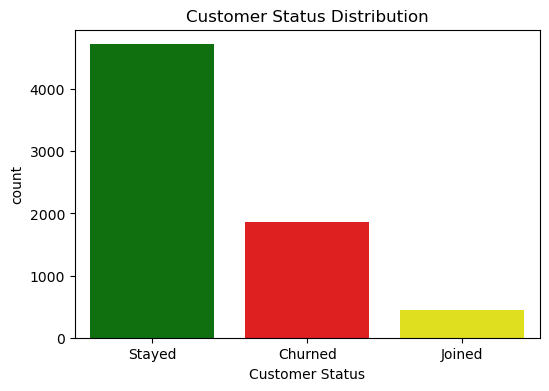

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Customer Status",
    hue="Customer Status",
    palette=["green", "red", "yellow"],
    legend=False
)

plt.title("Customer Status Distribution")
plt.show()

### Findings

The analysis shows that about 26.5% of customers churned, while only around 6.4% joined during the same period. This means the company is losing more customers than it is gaining, which indicates negative growth. If this trend continues, overall revenue will continue to decline. To address this issue, the company should focus more on retaining existing customers rather than only acquiring new ones. Loyalty programs, proactive customer engagement, and early communication with at-risk customers can help reduce churn.


### Research Question 2
Are churned customers different from stayed customers?
Compare Numerical Features

In [35]:
profile_summary = df.groupby("Customer Status")[
                            ["Age","Tenure in Months","Monthly Charge","Total Revenue"]
].mean()

profile_summary

,Age,Tenure in Months,Monthly Charge,Total Revenue
Customer Status,,,,
Churned,49.735688,17.979133,73.347592,1971.353569
Joined,42.870044,1.720264,42.775991,119.558921
Stayed,45.582415,41.041525,61.737415,3735.676297


### Findings
The data shows that churned customers usually have lower tenure compared to customers who stayed. Many churned customers also pay slightly higher monthly charges, while customers who stayed generate higher total revenue. This suggests that new customers are more likely to leave, and customers paying higher charges may feel they are not receiving enough value. To reduce churn, the company should improve the first-year customer experience, provide welcome offers for new customers, monitor customers with high monthly charges, and offer personalized plans based on customer usage.

### Research Question 3
What are the key drivers of churn?

In [39]:
# First create churn flag
def churn_flag(status):
    if status == "Churned":
        return 1
    else:
        return 0
    
df["Churn Flag"] = df["Customer Status"].apply(churn_flag)

# Contract Type vs Churn
contract_churn = df.groupby("Contract")["Churn Flag"].mean() * 100
contract_churn.sort_values(ascending=False)

Contract
Month-to-Month    45.844875
One Year          10.709677
Two Year           2.549124
Name: Churn Flag, dtype: float64

### Visualization
Contract Type vs Churn

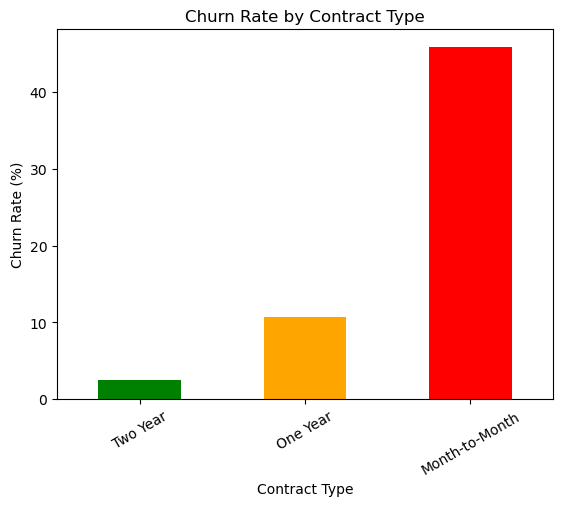

In [84]:
contract_churn.sort_values().plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.xticks(rotation=30)
plt.show()

### Churn Rate by Tenure Group

In [46]:
def tenure_group(months):
    if months <=12:
        return "0-12 Months"
    elif months <=24:
        return "13-24 Months"
    elif months <=48:
        return "25-48 Months"
    else:
        return "49+ Months"
    
df["Tenure Group"] = df["Tenure in Months"].apply(tenure_group)


tenure_churn = df.groupby("Tenure Group")["churn Flag"].mean()*100
tenure_churn.sort_values(ascending=False)

Tenure Group
0-12 Months     47.438243
13-24 Months    28.710938
25-48 Months    20.388959
49+ Months       9.513176
Name: churn Flag, dtype: float64

### Cross Analysis: Contract vs Tenure

In [47]:
pd.crosstab(df["Tenure Group"], df["Contract"], normalize="columns") * 100

Contract,Month-to-Month,One Year,Two Year
Tenure Group,,,
0-12 Months,52.991690,9.419355,6.744557
13-24 Months,19.002770,13.870968,6.532130
25-48 Months,19.806094,35.225806,17.684546
49+ Months,8.199446,41.483871,69.038768


### Findings
The analysis shows that month-to-month customers have the highest churn rate at around 46%, compared to about 10% for one-year contracts and only 2–3% for two-year contracts. This clearly shows that customers without long-term commitment are much more likely to leave. Additionally, a significant portion of churned customers reported leaving due to better competitor offers (around 40–45%), while others mentioned service-related issues and dissatisfaction.

This indicates that contract type is a major churn driver, and competitive pressure plays a strong role in customer loss. To reduce churn, the company should encourage customers to shift toward long-term contracts through incentives, improve bundle offers and device plans to compete better in the market, strengthen customer service quality, and respond quickly to customer complaints to improve satisfaction.

### Research Question 4
Is the company losing high-value customers?

Define high-value customers: (Top 25%)

In [57]:
high_value_threshold  = df["Total Revenue"].quantile(0.75)
def high_value(revenue):
    if revenue >=high_value_threshold:
        return True
    else:
        return False
    
df["High Value Flag"] = df["Total Revenue"].apply(high_value)
df.groupby("High Value Flag")["churn Flag"].mean() * 100

High Value Flag
False    30.443014
True     14.821124
Name: churn Flag, dtype: float64

### Revenue Impact
- Revenue Loss Due to Churn

In [58]:
revenue_lost = df[df["Customer Status"] == "Churned"]["Total Revenue"].sum()
revenue_lost


3684459.8200000003

In [59]:
total_revenue = df["Total Revenue"].sum()

total_revenue

21371131.69

In [70]:
revenue_lost = df[df["Customer Status"]=="Churned"]["Total Revenue"].sum()
total_revenue = df["Total Revenue"].sum()

print("Revenue Loss Percentage: {:.2f}%".format((revenue_lost / total_revenue) * 100))

Revenue Loss Percentage: 17.24%


### Findings
The results indicate that high-value customers churn less compared to lower-value customers. However, overall churn still results in approximately 17% revenue loss, which is financially significant. Although high-value customers are relatively stable, the company is still losing a noticeable portion of revenue due to churn. To improve retention, the company should create special plans for high-value customers, offer priority support, provide exclusive rewards, and identify at-risk customers early before they decide to leave.

### Root Cause Analysis
* What are the main reasons customers leave?

In [71]:
churn_category_dist = df[df["Customer Status"] == "Churned"]["Churn Category"].value_counts(normalize=True) * 100

churn_category_dist

Churn Category
Competitor         44.997325
Dissatisfaction    17.174960
Attitude           16.800428
Price              11.289460
Other               9.737828
Name: proportion, dtype: float64

In [72]:
churn_reason_dist = df[df["Customer Status"] == "Churned"]["Churn Reason"].value_counts(normalize=True) * 100

churn_reason_dist.head(10)

Churn Reason
Competitor had better devices                16.746923
Competitor made better offer                 16.639914
Attitude of support person                   11.771001
Don't know                                    6.955591
Competitor offered more data                  6.260032
Competitor offered higher download speeds     5.350455
Attitude of service provider                  5.029428
Price too high                                4.173355
Product dissatisfaction                       4.119850
Network reliability                           3.852327
Name: proportion, dtype: float64

### Findings
The analysis shows that contract type plays a major role in churn. Month-to-month customers have the highest churn rate at around 46%, compared to about 10% for one-year contracts and only 2–3% for two-year contracts. This clearly shows that customers without long-term commitment are much more likely to leave.

Looking at churn categories, nearly 45% of churned customers left due to competitors, making it the largest reason for churn. Other major reasons include dissatisfaction (17%), attitude-related issues (16.8%), and price concerns (11.3%).

When we examine specific churn reasons, the top causes include:

- Competitor had better devices (16.7%)

- Competitor made better offers (16.6%)

- Attitude of support person (11.8%)

- Competitor offered more data (6.3%)

- Competitor offered higher download speeds (5.4%)

Price-related issues such as “price too high” account for only around 4.2%, which shows that competition and service experience matter more than pricing alone.

Overall, churn is mainly driven by competitive offers and service experience rather than just cost. To reduce churn, the company should encourage customers to shift to long-term contracts, improve bundle and device offerings, enhance service quality, and respond quickly to customer dissatisfaction.

# Conclusion

This analysis shows that the company is facing a high churn rate of about 26.5%, while only around 6.4% of customers joined. This means the company is losing customers faster than it is gaining them, which is a serious risk for long-term growth.

The main drivers of churn are:

- Month-to-month contracts (around 46% churn rate)

- Low tenure customers, especially in the first year

- Competitive pressure, with nearly 45% of churn due to better competitor offers

- Service dissatisfaction and support issues

Although high-value customers churn less, overall churn is causing around 17% revenue loss, which is financially significant.

Churn is not random. It is mainly driven by contract type, early customer lifecycle, and competitive factors. 

# Overall Solution to Improve Customer Retention

To reduce churn and improve customer retention, the company should focus on the following actions:

1) Promote Long-Term Contracts : 
Encourage customers to move from month-to-month plans to one-year or two-year contracts by offering discounts, rewards, or bundled benefits.


2) Improve First-Year Customer Experience: 
Since new customers are more likely to churn, the company should strengthen onboarding, provide welcome offers, and engage customers early in their lifecycle.

3) Strengthen Competitive Offers: 
Many customers leave because competitors provide better devices, more data, or better plans. The company should review pricing, device bundles, and data packages to stay competitive.

4) Improve Customer Service Quality: 
Service attitude and dissatisfaction are key reasons for churn. Training support staff and improving response time can reduce customer frustration.

5) Monitor At-Risk Customers: 
Use data such as tenure, contract type, and monthly charges to identify high-risk customers early and take preventive action before they leave.

# Final Business Insight

Churn reduction should be the company’s top priority. By focusing on long-term contracts, early engagement, better competitive positioning, and improved service quality, the company can reduce churn, protect revenue, and achieve stable long-term growth.